# Setup

In [ ]:

# Install required libraries
#!pip install lightning torch torchvision torchaudio transformers decord pandas numpy torchmetrics timm einops
# Download Dataset (17G).
!curl -L -o accident.zip\
  https://www.kaggle.com/api/v1/datasets/download/picekl/accident
# Extract dataset
!unzip accident.zip

Streaming output truncated to the last 5000 lines.
  inflating: real_videos/ja62cRF2tbQ_00.mp4  
  inflating: real_videos/jaCr2wkcYJ8_00.mp4  
  inflating: real_videos/jbfxAh30dDc_00.mp4  
  inflating: real_videos/jc-fa_AjIXw_00.mp4  
  inflating: real_videos/jecwwv5-8Q0_00.mp4  
  inflating: real_videos/jfGiD4S9OiA_00.mp4  
  inflating: real_videos/jgAGNNIG13E_00.mp4  
  inflating: real_videos/jhkWGmAajmE_00.mp4  
  inflating: real_videos/jiOupTjSods_00.mp4  
  inflating: real_videos/jiiHFFhdKPc_00.mp4  
  inflating: real_videos/jiliVB6lsKE_00.mp4  
  inflating: real_videos/jnarvwUc5NU_00.mp4  
  inflating: real_videos/jndtah0zyZ4_00.mp4  
  inflating: real_videos/joRCqlk5sSA_00.mp4  
  inflating: real_videos/jopSKVpAIos_00.mp4  
  inflating: real_videos/jq-5EaxSR3M_00.mp4  
  inflating: real_videos/jrbryXS0w74_00.mp4  
  inflating: real_videos/jriayW0n33c_00.mp4  
  inflating: real_videos/jsh--BYn0pc_00.mp4  
  inflating: real_videos/ju6wnVi72qI_00.mp4  
  inflating: real_videos/jvM9

# Data Analysis

--- Class Imbalance Analysis ---

Task: accident_type
  Unique Classes: 5
  Imbalance Ratio: 5.81 (Goal is close to 1.0)

Task: region
  Unique Classes: 20
  Imbalance Ratio: 210.00 (Goal is close to 1.0)
  CRITICAL: 4 classes represent <1% of data.

Task: scene_layout
  Unique Classes: 8
  Imbalance Ratio: 117.12 (Goal is close to 1.0)
  CRITICAL: 2 classes represent <1% of data.

Task: weather
  Unique Classes: 3
  Imbalance Ratio: 14.74 (Goal is close to 1.0)

Task: day_time
  Unique Classes: 2
  Imbalance Ratio: 2.11 (Goal is close to 1.0)

Task: rollover
  Unique Classes: 2
  Imbalance Ratio: 7.77 (Goal is close to 1.0)


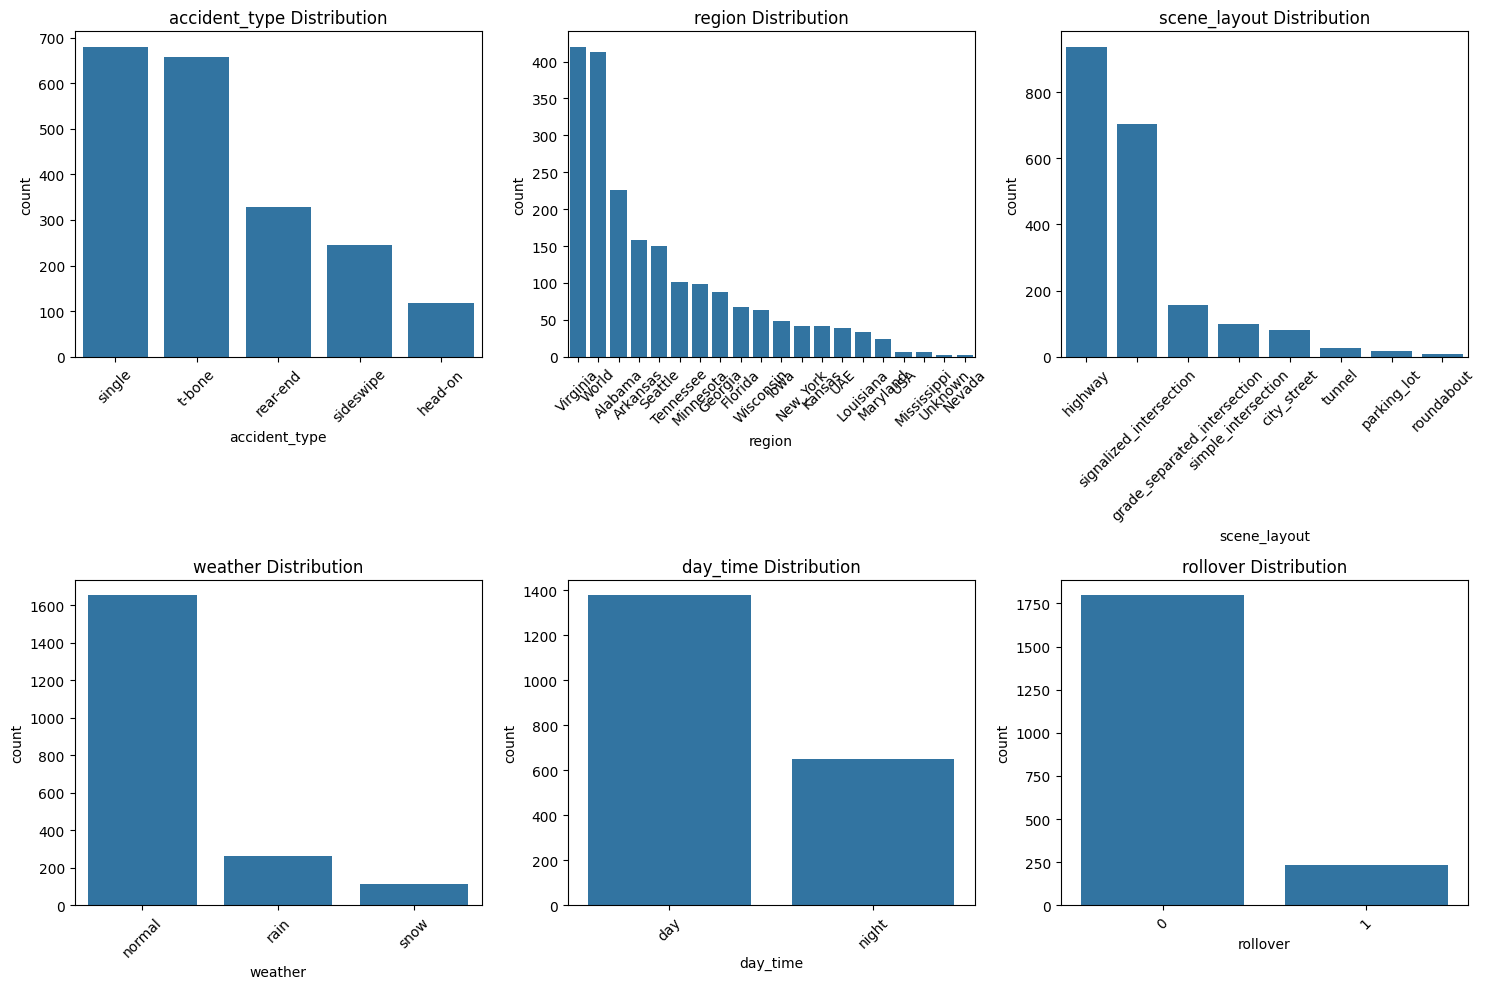

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

def analyze_traffic_data(csv_path, cat_tasks):
    df = pd.read_csv(csv_path)
    if 'type' in df.columns and 'accident_type' not in df.columns:
        df = df.rename(columns={'type': 'accident_type'})
    print("--- Class Imbalance Analysis ---")
    # 1. Distribution and Imbalance Ratio
    for col in cat_tasks:
        if col not in df.columns:
            continue
        counts = df[col].value_counts()
        total = len(df)
        # Imbalance Ratio: Majority / Minority
        ir = counts.max() / counts.min() if counts.min() > 0 else float('inf')
        print(f"\nTask: {col}")
        print(f"  Unique Classes: {len(counts)}")
        print(f"  Imbalance Ratio: {ir:.2f} (Goal is close to 1.0)")
        # Display small classes
        rare_classes = counts[counts / total < 0.01]
        if not rare_classes.empty:
            print(f"  CRITICAL: {len(rare_classes)} classes represent <1% of data.")
    # 2. Visualization
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(cat_tasks, 1):
        if col not in df.columns:
            continue
        plt.subplot(2, 3, i)
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'{col} Distribution')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return df

# Run analysis
cat_tasks_real = ['accident_type', 'region', 'scene_layout', 'weather', 'day_time', 'rollover']
df_real = analyze_traffic_data("metadata-real.csv", cat_tasks_real)

--- Class Imbalance Analysis ---

Task: accident_type
  Unique Classes: 5
  Imbalance Ratio: 12.03 (Goal is close to 1.0)

Task: weather
  Unique Classes: 5
  Imbalance Ratio: 1.51 (Goal is close to 1.0)


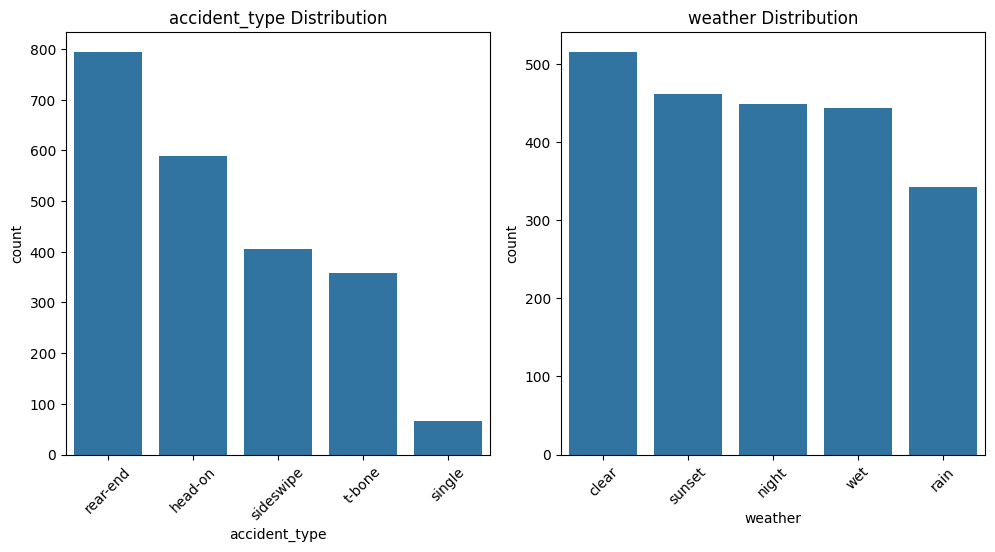

In [ ]:
# metadata-synthetic.csv only shares 'type', 'weather', 'duration' features
cat_tasks_synthetic = ['accident_type', 'weather']
df_synthetic = analyze_traffic_data(base_path+"metadata-synthetic.csv", cat_tasks_synthetic)

The weather feature has different modalities between real and synthetic datasets

In [ ]:
# Prepare the dataset (real + synthetic data)
df_synthetic.rename(columns={'rgb_path': 'path'}, inplace=True)
df_synthetic['data_origin'] = 'synthetic'
df_synthetic['split_in_distribution'] = 'train'
df_synthetic['split_geo_aware'] = 'train'
df_real['data_origin'] = 'real'
cols = [
  'path',
  'accident_type',
  'accident_frame',
  'duration',
  'split_in_distribution',
  'split_geo_aware',
  'data_origin'
]
# Complete the concat
df_full = pd.concat([df_real[cols], df_synthetic[cols]], ignore_index=True)
df_full.to_csv('metadata-real-and-synthetic.csv', index=False)

--- Class Imbalance Analysis ---

Task: accident_type
  Unique Classes: 5
  Imbalance Ratio: 1.73 (Goal is close to 1.0)


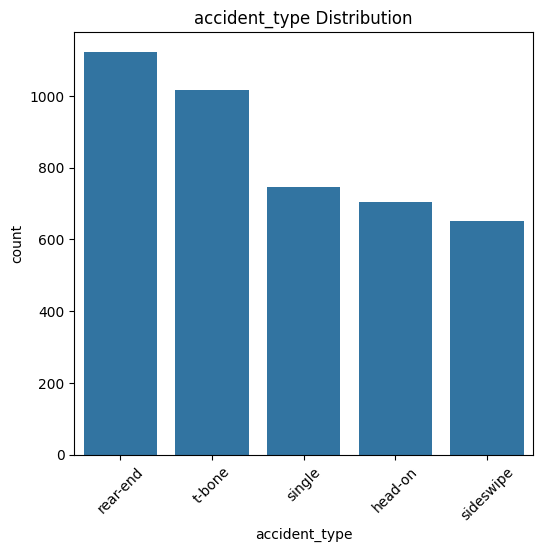

In [ ]:
df_synthetic = analyze_traffic_data('metadata-real-and-synthetic.csv', ['accident_type'])

DATA ANALYSIS REPORT & FUTURE WORK:

    1. Environmental Context (Weather): Currently excluded due to high class imbalance (1:14) and information asymmetry as well as real vs synthetic data concerns which could hurt model generalization.
       
    2. Temporal Features (Time of Day): Not used in MVP. Future work could inject
       sinusoidal 'time-of-day' features to account for rush-hour congestion
       patterns affecting emergency response times.
       
    3. Structural Incident Data (Rollover/Severity): Integrating binary flags for
       'Rollover' or 'Multi-vehicle' as secondary classification heads could
       refine the 'Duration' variance, reducing uncertainty for major crashes.
       
    4. Backbone Fine-tuning: Currently uses frozen V-JEPA 2 Large features.
       Unfreezing late layers of the ViT-L could improve performance on specific
       highway textures and lighting conditions.

# Modeling

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from decord import VideoReader, cpu

class TrafficDataset(Dataset):
    def __init__(self, df, cat_tasks, mappings, processor, num_frames=64):
        self.df = df
        self.processor = processor
        self.cat_tasks = cat_tasks
        self.mappings = mappings
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            vr = VideoReader(row['path'], ctx=cpu(0))
            impact = row['accident_frame']
            # Windowing: 32 frames before and after impact for a 64-frame clip
            start = max(0, impact - 32)
            end = min(len(vr) - 1, impact + 32)
            indices = np.linspace(start, end, self.num_frames).astype(int)
            frames = vr.get_batch(indices).asnumpy()
            # Processor handles normalization to [3, 256, 256]
            pixel_values = self.processor(list(frames), return_tensors="pt")['pixel_values'].squeeze(0)
        except Exception:
            pixel_values = torch.zeros((self.num_frames, 3, 256, 256))

        targets = {}
        for col in self.cat_tasks:
            label_str = str(row[col])
            idx_val = self.mappings[col].get(label_str, 0)
            targets[col] = torch.tensor(idx_val, dtype=torch.long)

        # Force float32 for regression to match loss function precision
        targets['duration'] = torch.tensor(float(row['duration']), dtype=torch.float32)
        return pixel_values, targets

In [ ]:
import lightning as L


class TrafficDataModule(L.LightningDataModule):
    def __init__(self, df, batch_size=2, num_frames=64, num_workers=2, split_type='geo_aware'):
        super().__init__()
        self.df = df
        self.batch_size = batch_size
        self.num_frames = num_frames
        self.num_workers = num_workers
        # Training difficulty ('in_distribution' or 'geo_aware')
        # 'in_distribution' tests standard accuracy by randomly shuffling all locations into train/test.
        # 'geo_aware' tests generalization by training on some cities and testing on entirely new ones.
        # Using 'geo_aware' allows the model to prove it can handle the domain shift of a real-world deployment.
        # The code supports both to allow benchmarking the "generalization gap".
        self.split_type = f'split_{split_type}'
        self.mappings = {}
        self.cat_tasks = ['accident_type']
        for col in self.cat_tasks:
            # Get unique labels, sort them for consistency, and create a lookup
            unique_labels = sorted(self.df[col].unique().astype(str))
            self.mappings[col] = {label: i for i, label in enumerate(unique_labels)}

    def compute_class_weights(self, df):
        weights_dict = {}
        for col, label_map in self.mappings.items():
            labels = df[col].map(label_map).values
            counts = torch.bincount(torch.tensor(labels, dtype=torch.long))
            total = len(labels)
            num_classes = len(counts)
            # Inverse frequency formula
            w = total / (num_classes * counts.float())
            weights_dict[col] = w
        return weights_dict

    def setup(self, stage=None):
        # 1. Filter rows based on the split type column
        full_train_df = self.df[self.df[self.split_type] == 'train'].copy()
        self.test_df = self.df[self.df[self.split_type] == 'test'].copy()
        # 2. Create a validation split from the train set
        # This is essential for monitoring the model during training
        self.val_df = full_train_df.sample(frac=0.1, random_state=42)
        self.train_df = full_train_df.drop(self.val_df.index)
        # 3. Compute weights strictly from the train split
        self.class_weights = self.compute_class_weights(self.train_df)
        # 4. Assign datasets based on the execution stage
        if stage == "fit" or stage is None:
            self.train_ds = TrafficDataset(
                 self.train_df,
                 self.cat_tasks,
                 self.mappings,
                 self.num_frames
            )
            self.val_ds = TrafficDataset(
                 self.val_df,
                 self.cat_tasks,
                 self.mappings,
                 self.num_frames
            )
        if stage == "test" or stage is None:
            self.test_ds = TrafficDataset(
                 self.test_df,
                 self.cat_tasks,
                 self.mappings,
                 self.num_frames
            )

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )

In [ ]:
class TrafficFeatureDataset(Dataset):
    def __init__(self, pt_file):
        # Load the dictionary saved by the extraction script
        data = torch.load(pt_file)
        self.features = data['features']   # Shape: [N, Hidden_Dim]
        self.targets = data['targets']     # Dict of tensors

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        # Return the vector and the dictionary of labels
        x = self.features[idx]
        y = {task: self.targets[task][idx] for task in self.targets.keys()}
        return x, y


class TrafficFeatureDataModule(L.LightningDataModule):
    def __init__(self, feature_dir="features", batch_size=1024):
        super().__init__()
        self.feature_dir = feature_dir
        self.batch_size = batch_size

    def setup(self, stage=None):
        if stage == "fit" or stage is None:
            self.train_ds = TrafficFeatureDataset(f"{self.feature_dir}/train_data.pt")
            self.val_ds = TrafficFeatureDataset(f"{self.feature_dir}/val_data.pt")

        if stage == "test" or stage is None:
            self.test_ds = TrafficFeatureDataset(f"{self.feature_dir}/test_data.pt")

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size)

In [ ]:
import torch.nn as nn
import torchmetrics
from transformers import AutoModel

class VJEPAAttentiveProbe(L.LightningModule):
    def __init__(self, mappings, model_id="facebook/vjepa2-vitl-fpc64-256", lr=1e-4):
        super().__init__()
        self.save_hyperparameters()

        # 1. Load Pretrained Backbone & Freeze
        # Intended as a fixed feature extractor
        self.backbone = AutoModel.from_pretrained(model_id)
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.backbone.eval()

        # 2. Attentive Pooler (The Learned Part)
        # This replaces mean pooling. It learns to 'attend' to relevant
        # spatial-temporal tokens (the crash) within the video sequence
        self.query = nn.Parameter(torch.randn(1, 1, 1024))
        self.attention = nn.MultiheadAttention(
            embed_dim=1024,
            num_heads=8,
            batch_first=True
        )

        # 3. Task-Specific Heads
        self.heads = nn.ModuleDict()
        self.f1_metrics = nn.ModuleDict()
        self.rmse_metrics = nn.ModuleDict()

        for name, label_map in mappings.items():
            self.heads[name] = nn.Sequential(
                nn.LayerNorm(1024),
                nn.Linear(1024, 512),
                nn.GELU(),
                nn.Linear(512, len(label_map))
            )
            self.f1_metrics[name] = torchmetrics.F1Score(
                task="multiclass", num_classes=len(label_map), average="macro"
            )

        self.heads['duration'] = nn.Linear(512, 2)
        self.rmse_metrics['duration'] = torchmetrics.MeanSquaredError(squared=False)

    def extract_features(self, x):
        return self.backbone(x).last_hidden_state

    def forward(self, x):
        # x: [Batch, Frames, C, H, W] raw video pixels
        with torch.no_grad():
            # Extract dense features (last_hidden_state)
            # Shape is typically [Batch, Tokens, 1024]
            outputs = self.backbone(x)
            tokens = outputs.last_hidden_state

        # Learnable Attentive Pooling
        # Scans tokens to prioritize 'accident' segments
        attn_out, _ = self.attention(
            self.query.expand(tokens.shape[0], -1, -1),
            tokens,
            tokens
        )
        shared_features = attn_out.squeeze(1) # [Batch, 1024]

        preds = {}
        for name, head in self.heads.items():
            if name == 'duration':
                # Use shared features for regression
                out = head(shared_features)
                preds[name] = {"mean": out[:, 0], "log_var": out[:, 1]}
            else:
                preds[name] = head(shared_features)
        return preds

    def training_step(self, batch, batch_idx):
        x, targets = batch
        preds = self(x)

        total_loss = 0
        for name in self.heads.keys():
            if name != 'duration':
                total_loss += nn.functional.cross_entropy(
                    preds[name], targets[name], label_smoothing=0.2
                )
            else:
                mean, var = preds[name]["mean"], torch.exp(preds[name]["log_var"])
                total_loss += nn.functional.gaussian_nll_loss(mean, targets[name], var)

        self.log("train/loss", total_loss, prog_bar=True)
        return total_loss

    def validation_step(self, batch, batch_idx):
        self._shared_eval(batch, "val")

    def test_step(self, batch, batch_idx):
        self._shared_eval(batch, "test")

    def _shared_eval(self, batch, prefix):
        x, targets = batch
        preds = self(x)
        log_data = {}
        for name in self.heads.keys():
            if name != 'duration':
                f1 = self.f1_metrics[name](preds[name], targets[name])
                log_data[f"{prefix}/f1_{name}"] = f1
            else:
                rmse = self.rmse_metrics[name](preds[name]["mean"], targets[name])
                log_data[f"{prefix}/rmse_{name}"] = rmse
        self.log_dict(log_data, prog_bar=True, on_epoch=True)

    def configure_optimizers(self):
        # We only train the Attention and Heads, keeping the backbone frozen
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=0.05)


# Feature Extraction

In [ ]:
import os
import json
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

def balanced_subsample(df, target_n, cat_col='accident_type', num_col='duration'):
    """Stratified sampling across classes and binned duration."""
    df = df.copy()
    # Bin duration into 5 quantiles to treat as categorical for stratification
    df['duration_bin'] = pd.qcut(df[num_col], q=5, labels=False, duplicates='drop')
    df['stratify_key'] = df[cat_col].astype(str) + "_" + df['duration_bin'].astype(str)

    # Drop groups with only 1 member
    counts = df['stratify_key'].value_counts()
    df = df[df['stratify_key'].isin(counts[counts > 1].index)]

    _, subset = train_test_split(
        df,
        test_size=min(target_n, len(df)),
        stratify=df['stratify_key'],
        random_state=42
    )
    return subset.drop(columns=['duration_bin', 'stratify_key'])

def extract_split_features(model, datamodule, save_dir="features"):
    os.makedirs(save_dir, exist_ok=True)
    datamodule.setup()

    # 1. Prepare Balanced Splits
    full_train = datamodule.df[datamodule.df[datamodule.split_type] == 'train']
    full_test = datamodule.test_df

    split_dfs = {
        "train": balanced_subsample(full_train, 1000),
        "val":   balanced_subsample(full_train.drop(full_train.sample(1000, random_state=42).index), 125),
        "test":  balanced_subsample(full_test, 125)
    }

    # 2. Multi-GPU Setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Move model to FP16 for T4 speedup
    model = model.to(device).to(torch.float16)

    if torch.cuda.device_count() > 1:
        print(f"🚀 Detected {torch.cuda.device_count()} GPUs. Wrapping in DataParallel...")
        # Wrap only the feature extraction logic if possible, or the whole model
        model = nn.DataParallel(model)

    model.eval()

    with torch.no_grad():
        for split, df in split_dfs.items():
            print(f"📦 Processing {split} split ({len(df)} samples)...")

            ds = type(datamodule.train_ds)(
                df, datamodule.cat_tasks, datamodule.mappings, datamodule.num_frames
            )

            # Optimized DataLoader for Kaggle
            loader = DataLoader(
                ds,
                batch_size=2,
                num_workers=2,
                pin_memory=True,
                #prefetch_factor=2
            )

            feats_list, target_accumulator = [], {task: [] for task in datamodule.mappings.keys()}
            if 'duration' not in target_accumulator: target_accumulator['duration'] = []

            for pixel_values, target_batch in tqdm(loader):
                # Send to GPU in half precision
                pixel_values = pixel_values.to(device, dtype=torch.float16, non_blocking=True)

                # Inference
                # Note: DataParallel handles splitting the batch across both T4s
                if isinstance(model, nn.DataParallel):
                    # Call the extract_features method specifically
                    f = model.module.extract_features(pixel_values).cpu()
                else:
                    f = model.extract_features(pixel_values).cpu()

                feats_list.append(f)

                # Collect Targets
                for k in target_accumulator.keys():
                    if k in target_batch:
                        target_accumulator[k].append(target_batch[k].cpu())

            # 3. Save aligned data
            torch.save({
                'features': torch.cat(feats_list),
                'targets': {k: torch.cat(v) for k, v in target_accumulator.items()}
            }, os.path.join(save_dir, f"{split}_data.pt"))

            # Save path mapping for debugging
            with open(os.path.join(save_dir, f"{split}_paths.json"), 'w') as f:
                json.dump(df['path'].tolist(), f, indent=4)

    print(f"✅ Extraction complete for all splits. Files saved to {save_dir}")

# extract_split_features(model, datamodule)

In [ ]:
df = pd.read_csv("metadata-real-and-synthetic.csv")
dm = TrafficDataModule(df,
                       batch_size=2,
                       num_workers=2)

model = VJEPAAttentiveProbe(mappings=dm.mappings)
extract_split_features(model, dm)

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

🚀 Detected 2 GPUs. Wrapping in DataParallel...
📦 Processing train split (1000 samples)...


 24%|██▍       | 30/125 [06:27<20:17, 12.82s/it]

# Train

In [ ]:
fdm = TrafficFeatureDataModule()
trainer = L.Trainer(
  accelerator="gpu",
  devices=1,
  precision="16-mixed",
  max_epochs=10
)
trainer.fit(model, fdm)

# Evaluate

In [ ]:
trainer.test(model, fdm)

In [ ]:
# TO DO
# Compare V-JEPA to a standard baseline
# Fine tune to minimize False Negative Rate
# Build a project architecture tree with relevant folder structure

# Quantize

In [ ]:
!pip install optimum[onnxruntime]

In [ ]:
from optimum.onnxruntime import ORTModelForVideoClassification
from optimum.onnxruntime.configuration import AutoQuantizationConfig
from optimum.onnxruntime import ORTQuantizer
import shutil
from pathlib import Path

# --- 0. THE BRIDGE STEP ---
# We save your trained variable to a temp folder.
# This creates the critical 'config.json' that Optimum needs to understand the architecture.
TEMP_DIR = Path("./temp_raw_model")
EXPORT_DIR = Path("./onnx_export")
QUANTIZED_DIR = Path("./onnx_quantized")

print("💾 Bridging: Saving in-memory model to disk...")
# Assuming 'model' is your trained variable
model.save_pretrained(TEMP_DIR)
# If you have a processor/feature_extractor, save it too!
# processor.save_pretrained(TEMP_DIR)

# --- 1. THE EXPORT STEP (Float32) ---
print("🚀 Loading and Exporting to ONNX...")
# Now we load it back into the Optimum Wrapper
ort_model = ORTModelForVideoClassification.from_pretrained(
    TEMP_DIR,
    export=True  # <--- Triggers the conversion using config.json
)
ort_model.save_pretrained(EXPORT_DIR)

# --- 2. THE QUANTIZATION STEP (Int8) ---
print("📉 Compressing to INT8...")
quantizer = ORTQuantizer.from_pretrained(ort_model)

# Create the config (AVX512 for Intel, ARM64 for M1/M2/M3)
q_config = AutoQuantizationConfig.avx512_vnni(is_static=False, per_channel=False)

quantizer.quantize(
    save_dir=QUANTIZED_DIR,
    quantization_config=q_config
)

# --- 3. CLEANUP & INSTRUCTIONS ---
print(f"\n✅ SUCCESS! Optimized model is ready.")
print(f"📂 Location: {QUANTIZED_DIR / 'model_quantized.onnx'}")
# shutil.rmtree(TEMP_DIR) # Optional: Clean up temp files

# Benchmark Models

In [ ]:
import time
import onnxruntime as ort

def benchmark_models(pytorch_model, onnx_path, dataloader, device="cpu"):
    """
    Runs a side-by-side comparison of PyTorch (FP32) vs ONNX (Int8).
    Args:
        pytorch_model: The loaded PyTorch model object (nn.Module).
        onnx_path: String path to the .onnx file.
        dataloader: A PyTorch DataLoader yielding (inputs, labels).
    """
    print(f"🏁 Starting Benchmark on {len(dataloader.dataset)} samples...")

    # 1. Setup Engines
    pytorch_model.to(device)
    pytorch_model.eval()

    # Load ONNX Engine
    ort_sess = ort.InferenceSession(onnx_path)
    input_name = ort_sess.get_inputs()[0].name

    # Metrics
    metrics = {
        "pt":   {"time": 0.0, "correct": 0},
        "onnx": {"time": 0.0, "correct": 0}
    }
    total_samples = 0

    # 2. Inference Loop
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            batch_size = inputs.size(0)
            total_samples += batch_size

            # --- A. PyTorch (Baseline) ---
            t0 = time.perf_counter()
            out_pt = pytorch_model(inputs)
            # Handle HF outputs which might be objects
            logits_pt = out_pt.logits if hasattr(out_pt, "logits") else out_pt
            metrics["pt"]["time"] += (time.perf_counter() - t0)

            pred_pt = torch.argmax(logits_pt, dim=1)
            metrics["pt"]["correct"] += (pred_pt == labels).sum().item()

            # --- B. ONNX Int8 (Production) ---
            # Convert Tensor to Numpy for ONNX
            inputs_np = inputs.cpu().numpy().astype(np.float32)

            t0 = time.perf_counter()
            logits_onnx = ort_sess.run(None, {input_name: inputs_np})[0]
            metrics["onnx"]["time"] += (time.perf_counter() - t0)

            pred_onnx = np.argmax(logits_onnx, axis=1)
            metrics["onnx"]["correct"] += (pred_onnx == labels.cpu().numpy()).sum()

    # 3. Calculate & Print Stats
    def calc_stats(key):
        acc = 100.0 * metrics[key]["correct"] / total_samples
        latency = (metrics[key]["time"] / total_samples) * 1000 # ms
        return acc, latency

    pt_acc, pt_lat = calc_stats("pt")
    onnx_acc, onnx_lat = calc_stats("onnx")

    speedup = pt_lat / onnx_lat
    acc_drop = pt_acc - onnx_acc

    print(f"\n📊 BENCHMARK REPORT")
    print(f"{'='*60}")
    print(f"{'Metric':<20} | {'PyTorch (Original)':<15} | {'ONNX (Int8)':<15}")
    print(f"{'-'*60}")
    print(f"{'Accuracy':<20} | {pt_acc:.2f}%{' '*8} | {onnx_acc:.2f}%")
    print(f"{'Avg Latency':<20} | {pt_lat:.2f} ms{' '*6} | {onnx_lat:.2f} ms")
    print(f"{'Throughput':<20} | {1000/pt_lat:.1f} FPS{' '*6} | {1000/onnx_lat:.1f} FPS")
    print(f"{'='*60}")
    print(f"🚀 Speedup: {speedup:.2f}x faster")
    print(f"⚖️  Trade-off: {acc_drop:.2f}% accuracy loss")

# benchmark_models(model, "backend/model_int8.onnx", test_loader)

In [ ]:
import cv2

def build_demo_assets(datamodule, output_root="backend"):
    """
    Samples 50 balanced events and clips the physical media.
    The backend will handle metadata/manifesting upon receiving these.
    """
    video_dir = os.path.join(output_root, "static/videos")
    image_dir = os.path.join(output_root, "static/images")

    for d in [video_dir, image_dir]:
        os.makedirs(d, exist_ok=True)

    datamodule.setup()
    test_df = datamodule.test_dataloader().dataset.df.reset_index(drop=True)

    # Balanced Sample: 10 per modality
    demo_df = test_df.groupby('accident_type').apply(
        lambda x: x.sample(min(10, len(x)), random_state=42), include_groups=False
    ).reset_index()

    print(f"🎬 Clipping 3s evidence for {len(demo_df)} samples...")
    for i, row in tqdm(demo_df.iterrows(), total=len(demo_df)):
        # We use a naming convention the Backend can easily parse
        vid_name = f"demo_{i:02d}.mp4"
        img_name = f"demo_{i:02d}.jpg"

        cap = cv2.VideoCapture(row['path'])
        fps = cap.get(cv2.CAP_PROP_FPS)
        acc_f = int(row['accident_frame'])

        # Save Snapshot (The 'Evidence')
        cap.set(cv2.CAP_PROP_POS_FRAMES, acc_f)
        ret, frame = cap.read()
        if ret: cv2.imwrite(os.path.join(image_dir, img_name), frame)

        # Save 3s Clip
        start = max(0, acc_f - int(1.5 * fps))
        end = min(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), acc_f + int(1.5 * fps))

        out_vid = cv2.VideoWriter(
            os.path.join(video_dir, vid_name),
            cv2.VideoWriter_fourcc(*'mp4v'),
            fps,
            (int(cap.get(3)), int(cap.get(4)))
        )

        cap.set(cv2.CAP_PROP_POS_FRAMES, start)
        for _ in range(start, end):
            r, f = cap.read()
            if not r: break
            out_vid.write(f)
        out_vid.release()
        cap.release()

    print(f"✅ Static assets hydrated. Backend will index these during simulation.")

build_demo_assets(dm)

In [ ]:

import os
import cv2
import json
import random
import torch
from tqdm import tqdm
from datetime import datetime, timedelta

def build_demo_assets(datamodule, output_root="backend"):
    # 1. Setup Dirs
    video_dir = os.path.join(output_root, "static/videos")
    image_dir = os.path.join(output_root, "static/images")
    manifest_path = os.path.join(output_root, "incident_manifest.json")

    for d in [video_dir, image_dir]:
        os.makedirs(d, exist_ok=True)

    datamodule.setup()
    # Get test data and ensure we have 'accident_type'
    test_df = datamodule.test_df.reset_index(drop=True)

    # 2. Balanced Sample: 2 per modality for 5 modalities = 10 total
    modalities = test_df['accident_type'].unique()[:5]
    demo_df = test_df[test_df['accident_type'].isin(modalities)].groupby('accident_type').apply(
        lambda x: x.sample(n=min(2, len(x)), random_state=42)
    ).reset_index(drop=True)

    manifest_data = []

    print(f"🎬 Clipping 3s evidence for {len(demo_df)} samples...")
    for i, row in tqdm(demo_df.iterrows(), total=len(demo_df)):
        event_id = f"EVT_{2024}_{i:03d}"
        vid_filename = f"{event_id}.mp4"
        img_filename = f"{event_id}.jpg"

        # --- VIDEO/IMAGE PROCESSING ---
        cap = cv2.VideoCapture(row['path'])
        fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 30
        acc_f = int(row['accident_frame'])

        # Save Image Snapshot
        cap.set(cv2.CAP_PROP_POS_FRAMES, acc_f)
        ret, frame = cap.read()
        if ret:
            cv2.imwrite(os.path.join(image_dir, img_filename), frame)

        # Save 3s Clip (1.5s before, 1.5s after)
        start = max(0, acc_f - int(1.5 * fps))
        end = min(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), acc_f + int(1.5 * fps))

        fourcc = cv2.VideoWriter_fourcc(*'vp09') # Web-friendly codec
        out_vid = cv2.VideoWriter(
            os.path.join(video_dir, vid_filename),
            fourcc, fps, (int(cap.get(3)), int(cap.get(4)))
        )

        cap.set(cv2.CAP_PROP_POS_FRAMES, start)
        for _ in range(start, end):
            r, f = cap.read()
            if not r: break
            out_vid.write(f)

        out_vid.release()
        cap.release()

        # --- FAKE AI METADATA GENERATION ---
        # Simulate model outputs based on actual data + some noise
        conf = random.uniform(0.75, 0.98)
        # Assuming severity is derived from confidence/type for the demo
        severity_map = {"Collisions": "high", "Stalled": "medium", "Other": "low"}
        sev = severity_map.get(row['accident_type'], "medium")

        # Build the JSON object following your Pydantic Schema
        incident = {
            "event_id": event_id,
            "timestamp": (datetime.utcnow() - timedelta(minutes=random.randint(1, 60))).isoformat(),
            "location": f"Highway Segment {random.randint(10, 99)}",
            "type": row['accident_type'], # Map to 'incident_type' via alias
            "severity": sev,
            "description": f"Detected {row['accident_type']} at frame {acc_f}.",
            "confidence": round(conf, 4),
            "duration_pred": float(row['duration']),
            "duration_uncertainty": round(random.uniform(0.1, 0.5), 4),
            "video_url": f"/static/videos/{vid_filename}",
            "image_url": f"/static/images/{img_filename}"
        }
        manifest_data.append(incident)

    # 3. Save the JSON Manifest
    with open(manifest_path, 'w') as f:
        json.dump(manifest_data, f, indent=4)

    print(f"✅ Assets & JSON manifest created at {output_root}")

# Execution
build_demo_assets(dm)